In [1]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\mahan\OneDrive\Desktop\DataCentre_Predictive_Maintenance_AI_Starter\.venv\Scripts\python.exe
3.7.9 (tags/v3.7.9:13c94747c7, Aug 17 2020, 16:30:00) [MSC v.1900 64 bit (AMD64)]


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Everything is working!")

Matplotlib is building the font cache; this may take a moment.


Pandas: 1.3.5
NumPy: 1.21.6
Everything is working!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/data_centre_sensor_data.csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Dataset loaded successfully!
Rows: 80640
Columns: 14


,Timestamp,Server_ID,Rack_ID,CPU_pct,Memory_pct,Disk_pct,Temperature_C,Network_MBps,Fan_RPM,Power_kW,Error_Count,Anomaly_Flag,Failure_Within_24h,Incident_Type
0,2026-08-01 00:00:00,SRV001,RACK01,43.93,53.81,44.97,29.40,379.98,1979.1,3.90,0,0,0,None
1,2026-08-01 00:05:00,SRV001,RACK01,44.87,52.42,45.75,28.87,378.61,1979.1,3.90,0,0,0,None
2,2026-08-01 00:10:00,SRV001,RACK01,47.05,55.08,44.17,29.33,405.30,2005.3,3.99,0,0,0,None
3,2026-08-01 00:15:00,SRV001,RACK01,49.73,54.99,44.02,30.16,395.84,2087.9,3.99,0,0,0,None
4,2026-08-01 00:20:00,SRV001,RACK01,40.76,55.92,46.55,28.59,420.90,1840.1,3.85,0,0,0,None


In [4]:
print("DATASET SHAPE")
print(df.shape)

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())


DATASET SHAPE
(80640, 14)

DATA TYPES
Timestamp              object
Server_ID              object
Rack_ID                object
CPU_pct               float64
Memory_pct            float64
Disk_pct              float64
Temperature_C         float64
Network_MBps          float64
Fan_RPM               float64
Power_kW              float64
Error_Count             int64
Anomaly_Flag            int64
Failure_Within_24h      int64
Incident_Type          object
dtype: object

MISSING VALUES
Timestamp             0
Server_ID             0
Rack_ID               0
CPU_pct               0
Memory_pct            0
Disk_pct              0
Temperature_C         0
Network_MBps          0
Fan_RPM               0
Power_kW              0
Error_Count           0
Anomaly_Flag          0
Failure_Within_24h    0
Incident_Type         0
dtype: int64

DUPLICATE ROWS
0


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CPU_pct,80640.0,45.453331,9.161407,17.59,38.9875,45.38,51.94,93.61
Memory_pct,80640.0,56.399646,6.441451,37.01,51.4500,55.99,61.16,79.94
Disk_pct,80640.0,74.798503,16.914365,39.22,60.1000,75.24,90.48,99.00
Temperature_C,80640.0,27.317811,1.932347,21.63,25.9000,27.17,28.64,37.34
Network_MBps,80640.0,412.001615,43.328265,185.29,384.0100,412.80,441.06,578.13
Fan_RPM,80640.0,2010.200382,177.736088,1518.90,1884.7000,1972.80,2106.80,3199.70
Power_kW,80640.0,3.844135,0.375613,2.73,3.5200,3.91,4.16,5.59
Error_Count,80640.0,0.213046,0.657925,0.00,0.0000,0.00,0.00,14.00
Anomaly_Flag,80640.0,0.264918,0.441292,0.00,0.0000,0.00,1.00,1.00
Failure_Within_24h,80640.0,0.129539,0.335797,0.00,0.0000,0.00,0.00,1.00


In [6]:
print("Number of servers:", df["Server_ID"].nunique())
print("Number of racks:", df["Rack_ID"].nunique())

print("\nServers:")
print(df["Server_ID"].unique())

print("\nRacks:")
print(df["Rack_ID"].unique())

Number of servers: 20
Number of racks: 4

Servers:
['SRV001' 'SRV002' 'SRV003' 'SRV004' 'SRV005' 'SRV006' 'SRV007' 'SRV008'
 'SRV009' 'SRV010' 'SRV011' 'SRV012' 'SRV013' 'SRV014' 'SRV015' 'SRV016'
 'SRV017' 'SRV018' 'SRV019' 'SRV020']

Racks:
['RACK01' 'RACK02' 'RACK03' 'RACK04']


In [7]:
print("ANOMALY DISTRIBUTION")
print(df["Anomaly_Flag"].value_counts())

print("\nANOMALY PERCENTAGE")
print(df["Anomaly_Flag"].value_counts(normalize=True) * 100)

print("\nFAILURE WITHIN 24 HOURS")
print(df["Failure_Within_24h"].value_counts())

print("\nFAILURE PERCENTAGE")
print(df["Failure_Within_24h"].value_counts(normalize=True) * 100)

ANOMALY DISTRIBUTION
0    59277
1    21363
Name: Anomaly_Flag, dtype: int64

ANOMALY PERCENTAGE
0    73.508185
1    26.491815
Name: Anomaly_Flag, dtype: float64

FAILURE WITHIN 24 HOURS
0    70194
1    10446
Name: Failure_Within_24h, dtype: int64

FAILURE PERCENTAGE
0    87.046131
1    12.953869
Name: Failure_Within_24h, dtype: float64


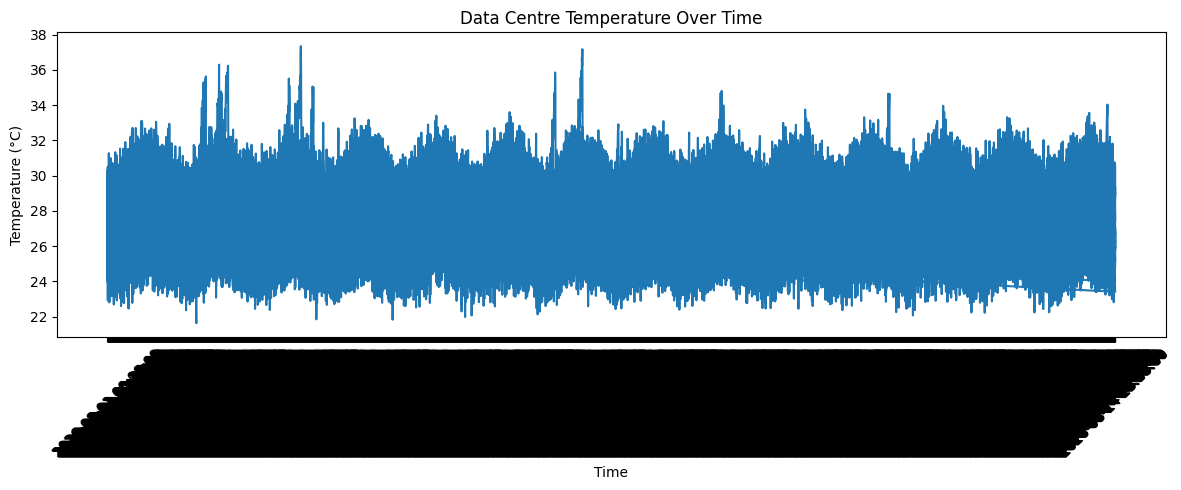

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(df["Timestamp"], df["Temperature_C"])

plt.title("Data Centre Temperature Over Time")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

<Figure size 1000x500 with 0 Axes>

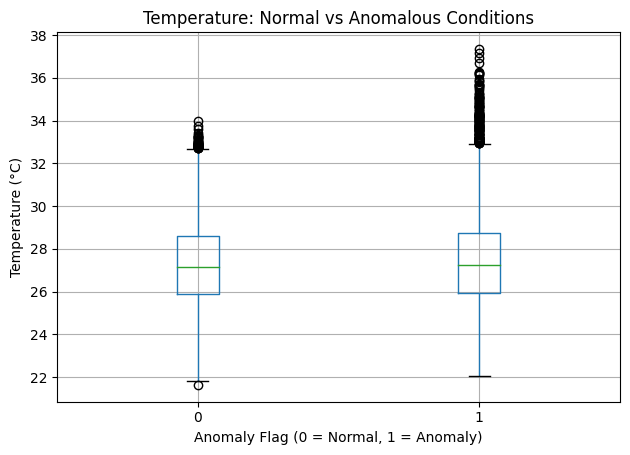

In [10]:
plt.figure(figsize=(10, 5))

df.boxplot(
    column="Temperature_C",
    by="Anomaly_Flag"
)

plt.title("Temperature: Normal vs Anomalous Conditions")
plt.suptitle("")
plt.xlabel("Anomaly Flag (0 = Normal, 1 = Anomaly)")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

In [11]:
sensor_cols = [
    "CPU_pct",
    "Memory_pct",
    "Disk_pct",
    "Temperature_C",
    "Network_MBps",
    "Fan_RPM",
    "Power_kW",
    "Error_Count"
]

df[sensor_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CPU_pct,80640.0,45.453331,9.161407,17.59,38.9875,45.38,51.94,93.61
Memory_pct,80640.0,56.399646,6.441451,37.01,51.4500,55.99,61.16,79.94
Disk_pct,80640.0,74.798503,16.914365,39.22,60.1000,75.24,90.48,99.00
Temperature_C,80640.0,27.317811,1.932347,21.63,25.9000,27.17,28.64,37.34
Network_MBps,80640.0,412.001615,43.328265,185.29,384.0100,412.80,441.06,578.13
Fan_RPM,80640.0,2010.200382,177.736088,1518.90,1884.7000,1972.80,2106.80,3199.70
Power_kW,80640.0,3.844135,0.375613,2.73,3.5200,3.91,4.16,5.59
Error_Count,80640.0,0.213046,0.657925,0.00,0.0000,0.00,0.00,14.00


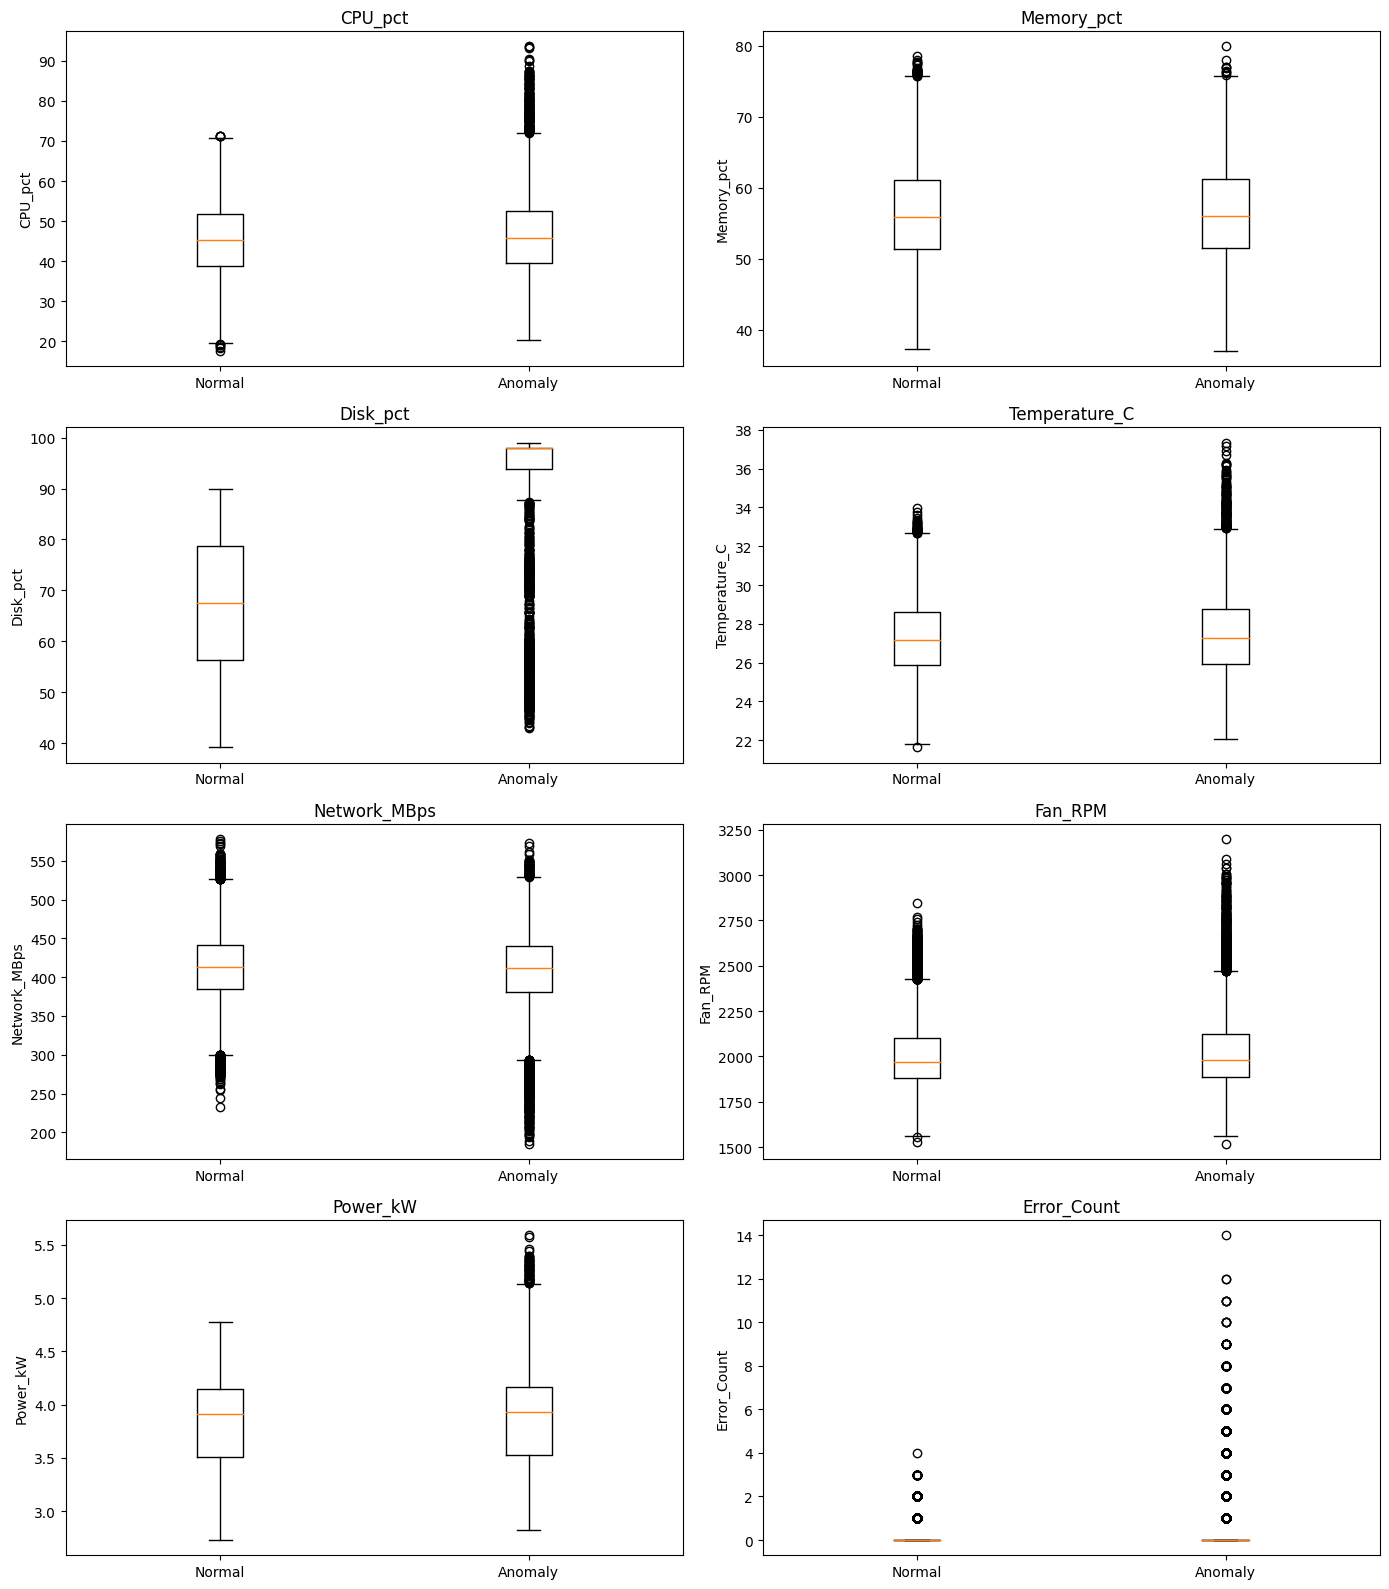

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

for ax, col in zip(axes.flatten(), sensor_cols):
    ax.boxplot([
        df.loc[df["Anomaly_Flag"] == 0, col].dropna(),
        df.loc[df["Anomaly_Flag"] == 1, col].dropna()
    ])
    ax.set_title(col)
    ax.set_xticklabels(["Normal", "Anomaly"])
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/raw/data_centre_sensor_data.csv")

# Convert timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Dataset shape:", df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Dataset shape: (80640, 14)

Missing values:
Timestamp             0
Server_ID             0
Rack_ID               0
CPU_pct               0
Memory_pct            0
Disk_pct              0
Temperature_C         0
Network_MBps          0
Fan_RPM               0
Power_kW              0
Error_Count           0
Anomaly_Flag          0
Failure_Within_24h    0
Incident_Type         0
dtype: int64

Duplicate rows: 0

Data types:
Timestamp             datetime64[ns]
Server_ID                     object
Rack_ID                       object
CPU_pct                      float64
Memory_pct                   float64
Disk_pct                     float64
Temperature_C                float64
Network_MBps                 float64
Fan_RPM                      float64
Power_kW                     float64
Error_Count                    int64
Anomaly_Flag                   int64
Failure_Within_24h             int64
Incident_Type                 object
dtype: object


In [14]:
print("Anomaly distribution:")
print(df["Anomaly_Flag"].value_counts())

print("\nAnomaly percentage:")
print(df["Anomaly_Flag"].value_counts(normalize=True) * 100)

print("\nFailure distribution:")
print(df["Failure_Within_24h"].value_counts())

print("\nFailure percentage:")
print(df["Failure_Within_24h"].value_counts(normalize=True) * 100)

Anomaly distribution:
0    59277
1    21363
Name: Anomaly_Flag, dtype: int64

Anomaly percentage:
0    73.508185
1    26.491815
Name: Anomaly_Flag, dtype: float64

Failure distribution:
0    70194
1    10446
Name: Failure_Within_24h, dtype: int64

Failure percentage:
0    87.046131
1    12.953869
Name: Failure_Within_24h, dtype: float64
